In [1]:
#Импорты для запуска в colab с гугл диска
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/Diplom_data/resonance_sorter')

Mounted at /content/drive


In [2]:
#Импорты функций из модулей
from src.time_series import load_multi_csv
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions
from src.criteria import process_multiplet

In [3]:
# Загрузка файла с углами и преобразование в необходимые форматы для функций построений графиков и модели
data_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.csv'
data = load_multi_csv(
    filepath=data_path,
    angle_columns=['phi_0_original', 'phi_1_original'],  # подставьте имена ваших колонок для углов из мультиплета
    period_column='period_ratio',
    time_column='time_years',
    angle_unit='deg',
    convert_to_xy=True
)

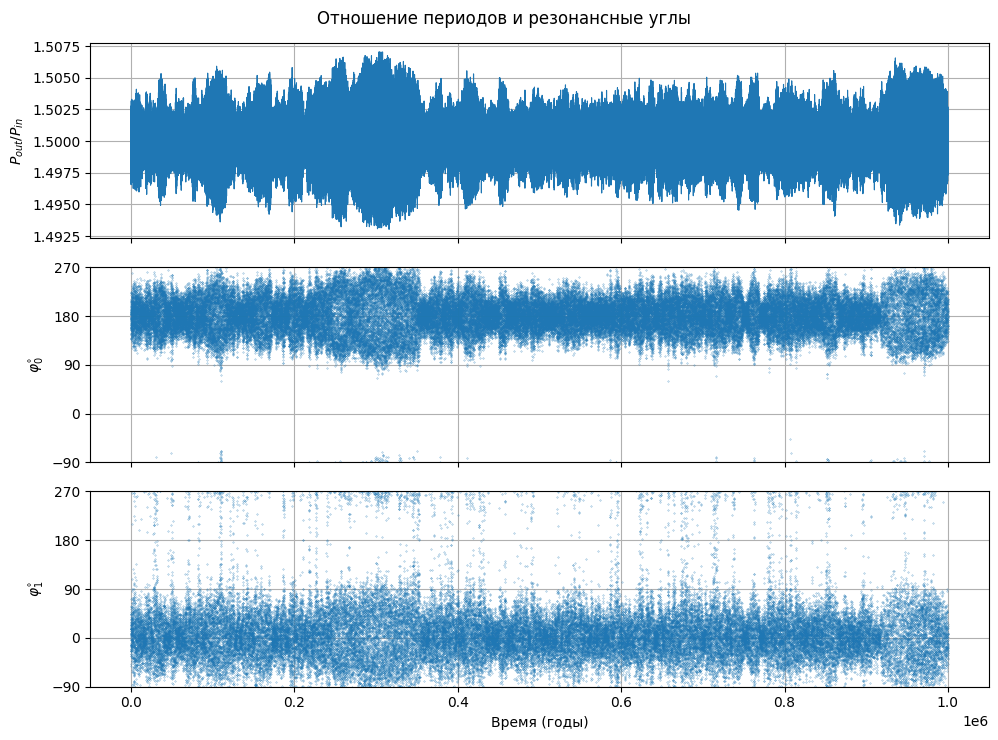

In [4]:
# Построить ряды из файла с углами и отношением периодов
plot_raw_multiplet(
    time_years=data['time_years'],
    period_ratio=data['period_ratio'],
    angles_deg_list=data['angles_deg'],
    title='Отношение периодов и резонансные углы'
    # save_path=''
)

In [5]:
# Разбиение на окна (пока реализован вариант разбиения без перекрытий между окнами)
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.
)


In [6]:
#Загрузка обученной модели ('1' --- модель обученная на оригинальном наборе данных с дисбалансом классов, "2" --- модель обученная на урезаном наборе данных (примеры были урезаны до миноритарного класса))
model = load_model('1', models_dir='/content/drive/MyDrive/Diplom_data/resonance_sorter/models/')

In [7]:
# Прогнозы модели для окон
probs = predict_multiplet(windows['angle_windows'], model)

In [8]:
# Наибольшая веротяность для каждого окна (наиболее вроятная метка <<0>> --- циркуляция, <<1>> --- либрация, <<2>> --- переходный режим)
classes = [predict_classes_from_proba(p) for p in probs]

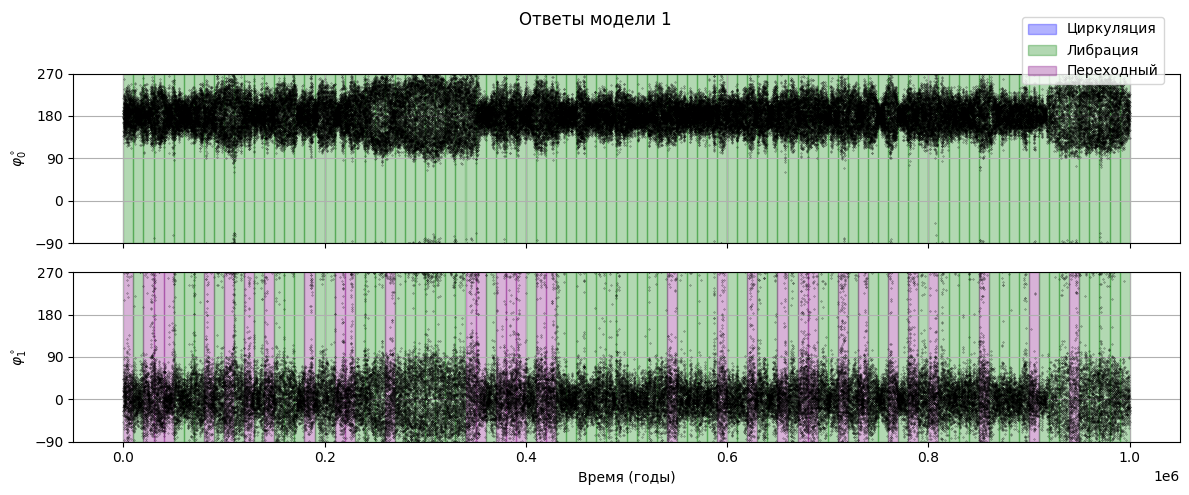

In [9]:
# Расскрасить окна на основе ответов модели (картинка)
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Ответы модели 1',
    # save_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/notebook/predict_TOI1136_model1.png'

)

In [10]:
# Вычисление резонансных сегментов.
"""
В данном случае критерий: минимально необходимая длинна окон (сегмента) либрации агрегированных меток окон (>=30) (сведены к одной с приоритетом:1 (либрация) > 2 (переходный) > 0 (циркуляция))
, со скользящим окном для проверки (на 6 окон не более двух меток отличных от либрации)"""
segments = process_multiplet(
    class_labels_list=classes,
    window_bounds=windows['window_bounds'],
    time_years=data['time_years'],
    period_ratio=data['period_ratio'],
    expected_ratio=1.5,#резонансное отношение периодов для планет ((p+q)\p, в данном случае 3/2)
    min_librations=30,
    max_consecutive_nonlib=2,# не более двух меток отличных от либрации на скользящем окне
    sliding_window_size=6,#длина скользящего окна
    max_nonlib_in_sliding=2
)

In [11]:
segments

[{'librations_count': 100,
  'start_window': 0,
  'end_window': 99,
  't_start_years': np.float32(0.0),
  't_end_years': np.float32(999997.5),
  'duration_years': np.float32(999997.5),
  'Delta_max': np.float32(0.0070397854)}]

In [14]:
segments[0]['duration_years']#Длительность интервала либрации

np.float32(999997.5)

In [16]:
segments[0]['Delta_max']# Максимально значение резонансного отступа резонанса данного резонанса 3:2 на интервале либрации между 1 и 2 планетами

np.float32(0.0070397854)